In [ ]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
import anndata as ad
import json
import tqdm

# MapMyCells mapping pipeline
from cell_type_mapper.test_utils.cache_wrapper import AbcCacheWrapper
from cell_type_mapper.cli.from_specified_markers import FromSpecifiedMarkersRunner

# Local imports
from xenium_analysis_tools.map_xenium.map_sections import ( 
    get_abc_paths, 
    get_v1_merfish_cells,
    get_nodes_to_drop,
    validate_input_adata,
    format_mapping_outputs,
)

from xenium_analysis_tools.map_xenium.map_sections import mapping_plots as mp


from xenium_analysis_tools.utils.io_utils import (
    load_config, 
)

from xenium_analysis_tools.utils.sd_utils import (
    get_dataset_paths
)

# Environment setup (limit threads for numpy operations)
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

In [18]:
def combine_sections_adatas(sections_paths, dataset_info={}):
    # Initialize
    sections_adatas: list[ad.AnnData] = []
    section_md_rows: list[dict] = []
    # Loop through sections
    for s_path in tqdm.tqdm(sections_paths, desc='Loading section adatas'):
        # Load anndata from table
        adata = ad.read_zarr(s_path / 'tables' / 'table')

        # Format section/cell ids
        section_num = int(s_path.stem.split('_')[1])
        adata.obs['section'] = section_num
        adata.obs['original_cell_id'] = adata.obs['cell_id']
        adata.obs['cell_id'] = [f"{c_id}_{sec}" for c_id, sec in zip(adata.obs['cell_id'], adata.obs['section'])]
        adata.obs.set_index('cell_id', inplace=True, drop=False)

        # Add metadata
        mouse_id = dataset_info.get('dataset_id', None)
        adata.obs['mouse_id'] = mouse_id
        genotype = dataset_info.get('genotype', None)
        adata.obs['genotype'] = genotype
        adata.obs['sectioning_depth'] = dataset_info.get('sectioning_depth', None)
        section_thickness = dataset_info.get('sections_thickness', None)
        if section_thickness is not None:
            adata.obs['sections_thickness'] = section_thickness
            section_start_depth = section_thickness * (section_num - 1)
            section_end_depth = section_thickness * section_num
            adata.obs["section_start_depth"] = section_start_depth
            adata.obs["section_end_depth"] = section_end_depth

        section_md = {
            "mouse_id": mouse_id,
            "section": section_num,
            "genotype": genotype,
            "section_start_depth": section_start_depth,
            "section_end_depth": section_end_depth,
        }
        for md, vals in adata.uns.get("section_metadata", {}).items():
            if md not in {"images", "xenium_explorer_files"}:
                section_md[md] = vals

        section_md_rows.append(section_md)

        # Clear bulky containers
        adata.uns = {}
        adata.obsm = {}
        sections_adatas.append(adata)
        del adata
    
    # Combine all sections into a single AnnData object
    sections_adatas = ad.concat(
        sections_adatas, 
        axis=0, 
        join="outer", 
        merge="same"
    )
    # Create section metadata dataframe
    sections_metadata = pd.DataFrame(section_md_rows)

    obj_cols = sections_metadata.columns[sections_metadata.dtypes == "object"]
    sections_metadata[obj_cols] = sections_metadata[obj_cols].astype(str)
    sections_adatas.uns['sections_metadata'] = sections_metadata

    sections_adatas.var['gene_symbol'] = sections_adatas.var.index
    sections_adatas.var.set_index(sections_adatas.var['gene_ids'], inplace=True, drop=False)

    return sections_adatas

In [ ]:
# Paths/typical configs
config = load_config('/root/capsule/code/xenium_analysis_tools/src/xenium_analysis_tools/example_notebooks/params.json')
config_paths = config['paths']
mapping_config = config['mapping_config']

# Overwrite any existing mapping outputs
overwrite_input_adata = False
overwrite_mapping_results = False
overwrite_formatted_outputs = False

In [20]:
dataset_id = 756772

paths = get_dataset_paths(dataset_id)
dataset_output_folder = Path(paths['scratch_root']) / f'xenium_{dataset_id}_mapping'
input_folder = dataset_output_folder / mapping_config['input_data_folder_name']
output_folder = dataset_output_folder / mapping_config['mapped_data_folder_name']
input_folder.mkdir(parents=True, exist_ok=True)
output_folder.mkdir(parents=True, exist_ok=True)

datasets_naming_dict_path = Path("/root/capsule/code") / 'datasets_names_dict.json'
with open(datasets_naming_dict_path) as f:
    datasets_naming_dict = json.load(f)

abc_atlas_path = Path(config_paths['abc_path'])
abc_cache = AbcCacheWrapper.from_local_cache(abc_atlas_path)
precomputed_stats_path, mouse_markers_path, gene_mapper_db_path = get_abc_paths(abc_cache)

# Layer selection
drop_layers = ['VISp6a', 'VISp6b']

# Output files
extended_results_path = output_folder / mapping_config['extended_results_name']
basic_results_path = output_folder / mapping_config['basic_results_name']

/opt/conda/lib/python3.12/site-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:519: MissingLocalManifestWarning: This cache directory appears to contain data files, but it has no record of what those files are. Unless running as a LocalCache, files will be re-downloaded.
  warnings.warn(msg, MissingLocalManifestWarning)
/opt/conda/lib/python3.12/site-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:1490: ReadOnlyLocalCacheWarning: LocalCache is a read only directory and cannot
                save the last used manifest.
                Current Manifest: releases/20260228/manifest.json
  warnings.warn(


## Combine sections and create input AnnData

In [21]:
# Dataset folder
processed_data_folder = paths['sdata_path']
sections_paths = sorted(list(processed_data_folder.glob('section_*.zarr')), key=lambda x: int(x.stem.split('_')[1]))
dataset_info = datasets_naming_dict.get(str(dataset_id), {})
dataset_info['dataset_id'] = dataset_id
input_adata_path = Path(input_folder / 'input_cellxgene.h5ad')
if input_adata_path.exists() and not overwrite_input_adata:
    print(f"Input anndata file already exists at {input_adata_path}. Skipping since overwrite_input_adata is set to False.")
else:
    sections_adatas = combine_sections_adatas(sections_paths, dataset_info)
    sections_adatas.write_h5ad(input_adata_path)

Input anndata file already exists at /root/capsule/scratch/xenium_756772_mapping/input_data/input_cellxgene.h5ad. Skipping since overwrite_input_adata is set to False.


## Drop nodes

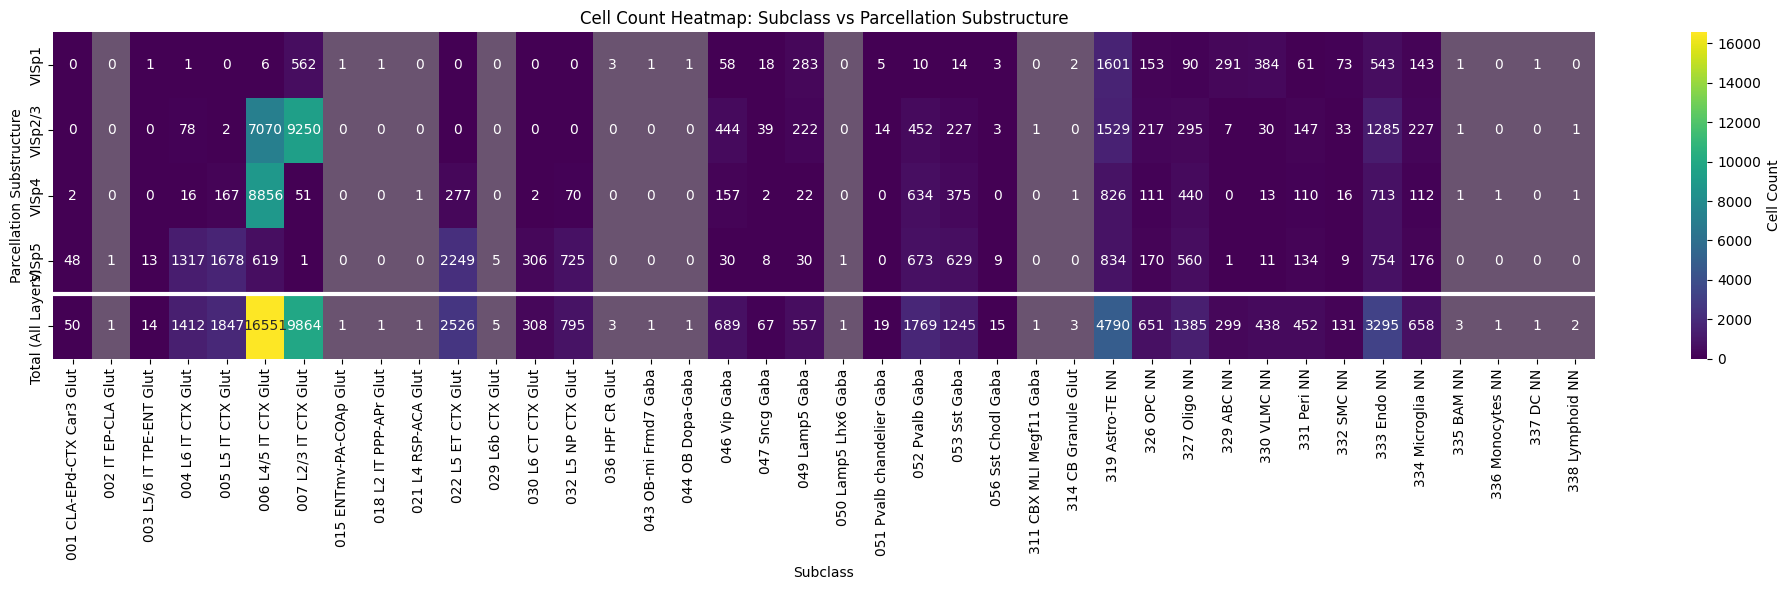

Dropping 313 subclass nodes not present in V1 MERFISH data with at least 6 cell(s).


In [22]:
# Taxonomy filters - nodes to drop for mapping
nodes_to_drop=[]
# If specified any specific nodes to drop in config
drop_nodes_dict = mapping_config.get('drop_nodes_dict', None)
if drop_nodes_dict:
    for h_level in drop_nodes_dict:
        nodes_to_drop.extend([(h_level, cl) for cl in drop_nodes_dict[h_level]])
    print(f"Dropping {len(nodes_to_drop)} nodes based on drop_nodes_dict.")
# Filter to only V1 cells
filter_v1_types_config = mapping_config.get('filter_mapping_v1_types', None)
if filter_v1_types_config and filter_v1_types_config.get('enabled', False):
    h_level = filter_v1_types_config.get('h_level', 'subclass')
    min_cells = filter_v1_types_config.get('min_cells', 0)
    v1_types_df_name = filter_v1_types_config.get('saved_df_name', 'v1_merfish_cells.csv')
    if v1_types_df_name:
        v1_types_path = Path(paths['data_root']) / v1_types_df_name
    else:
        v1_types_path = None
    v1_merfish_cells = get_v1_merfish_cells(abc_cache, df_path=v1_types_path)
    if drop_layers:
        v1_merfish_cells = v1_merfish_cells.loc[~v1_merfish_cells['parcellation_substructure'].isin(drop_layers)]
    mp.plot_cell_counts_heatmap(v1_merfish_cells, drop_layers=drop_layers, min_cells=min_cells)
    v1_nodes_to_drop = get_nodes_to_drop(v1_merfish_cells, abc_cache, h_level=h_level, min_cells=min_cells)
    print(f"Dropping {len(v1_nodes_to_drop)} {h_level} nodes not present in V1 MERFISH data with at least {min_cells if min_cells>0 else 1} cell(s).")
    nodes_to_drop.extend(v1_nodes_to_drop)

## Validate input data

In [23]:
query_path = validate_input_adata(input_adata_path, input_adata_path.parent, mouse_markers_path, gene_mapper_db_path)

Starting validation of input data...
DONE VALIDATING ../input_cellxgene.h5ad; no changes required
CLEANING UP
Using validated path: /root/capsule/scratch/xenium_756772_mapping/input_data/input_cellxgene.h5ad


## Mapping params

In [31]:
# ----- Mapper parameters -----
mapping_params = mapping_config.get('mapping_params', {})
mapping_params['nodes_to_drop'] = nodes_to_drop

# Type assignment parameters for mapper
type_assignment = {
    'normalization': 'raw',
    'bootstrap_iteration': mapping_params.get('bootstrap_iteration', 100),
    'bootstrap_factor': mapping_params.get('bootstrap_factor', 0.5),
    'n_runners_up': mapping_params.get('n_runners_up', 2),
    'n_processors': os.cpu_count()
}

mapper_config = {
    'query_path': query_path,
    'extended_result_path': str(extended_results_path),
    'csv_result_path': str(basic_results_path),
    'flatten': False,
    'precomputed_stats': {'path': precomputed_stats_path},
    'query_markers': {'serialized_lookup': mouse_markers_path},
    'type_assignment': type_assignment,
    'nodes_to_drop': mapping_params.get('nodes_to_drop', None),
    'verbose_stdout': True,
    'tmp_dir': '/tmp',
}

for key, val in mapper_config.items():
    if key != 'type_assignment':
        print(f"{key}: {val}")
    else:
        print(f"{key}:")
        for sub_key, sub_val in val.items():
            print(f"\t{sub_key}: {sub_val}")

query_path: /root/capsule/scratch/xenium_756772_mapping/input_data/input_cellxgene.h5ad
extended_result_path: /root/capsule/scratch/xenium_756772_mapping/mapped_data/extended_results.json
csv_result_path: /root/capsule/scratch/xenium_756772_mapping/mapped_data/basic_results.csv
flatten: False
precomputed_stats: {'path': '/root/capsule/data/abc_atlas/mapmycells/WMB-10X/20240831/precomputed_stats_ABC_revision_230821.h5'}
query_markers: {'serialized_lookup': '/root/capsule/data/abc_atlas/mapmycells/WMB-10X/20240831/mouse_markers_230821.json'}
type_assignment:
	normalization: raw
	bootstrap_iteration: 100
	bootstrap_factor: 0.5
	n_runners_up: 2
	n_processors: 16
nodes_to_drop: [('subclass', 'CS20230722_SUBC_002'), ('subclass', 'CS20230722_SUBC_008'), ('subclass', 'CS20230722_SUBC_009'), ('subclass', 'CS20230722_SUBC_010'), ('subclass', 'CS20230722_SUBC_011'), ('subclass', 'CS20230722_SUBC_012'), ('subclass', 'CS20230722_SUBC_013'), ('subclass', 'CS20230722_SUBC_014'), ('subclass', 'CS20230

## Run mapper

In [32]:
if basic_results_path.exists() and extended_results_path.exists() and not overwrite_mapping_results:
    print(f"Mapping results already exist at {basic_results_path} and {extended_results_path}. Skipping mapping.")
else:
    runner = FromSpecifiedMarkersRunner(args=[], input_data=mapper_config)
    runner.run()

=== Running Hierarchical Mapping 1.7.1 with config ===
{
  "gene_mapping": null,
  "nodes_to_drop": [
    [
      "subclass",
      "CS20230722_SUBC_002"
    ],
    [
      "subclass",
      "CS20230722_SUBC_008"
    ],
    [
      "subclass",
      "CS20230722_SUBC_009"
    ],
    [
      "subclass",
      "CS20230722_SUBC_010"
    ],
    [
      "subclass",
      "CS20230722_SUBC_011"
    ],
    [
      "subclass",
      "CS20230722_SUBC_012"
    ],
    [
      "subclass",
      "CS20230722_SUBC_013"
    ],
    [
      "subclass",
      "CS20230722_SUBC_014"
    ],
    [
      "subclass",
      "CS20230722_SUBC_015"
    ],
    [
      "subclass",
      "CS20230722_SUBC_016"
    ],
    [
      "subclass",
      "CS20230722_SUBC_017"
    ],
    [
      "subclass",
      "CS20230722_SUBC_018"
    ],
    [
      "subclass",
      "CS20230722_SUBC_019"
    ],
    [
      "subclass",
      "CS20230722_SUBC_020"
    ],
    [
      "subclass",
      "CS20230722_SUBC_021"
    ],
    [
      "

/src/cell-type-mapper/src/cell_type_mapper/cli/cli_log.py:104: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  self.env(f"anndata version: {anndata.__version__}")
/src/cell-type-mapper/src/cell_type_mapper/taxonomy/utils.py:253: UserWarning: This taxonomy has no mapping from leaf_node -> rows in the cell by gene matrix
  warnings.warn("This taxonomy has no mapping from leaf_node -> rows "


FILE TRACKER: copied ../input_cellxgene.h5ad to ../input_cellxgene_n0cs42ze.h5ad
BENCHMARK: spent 1.2457e-01 seconds validating config and copying data
using ../precomputed_stats_ABC_revision_230821.h56wv4khpm.h5 for precomputed_stats
reading taxonomy_tree from ../precomputed_stats_ABC_revision_230821.h56wv4khpm.h5
No gene_mapper_db provided. Assuming that query genes have already been mapped to the same species/authority as reference genes.


/src/cell-type-mapper/src/cell_type_mapper/cli/cli_log.py:73: UserWarning: 6288 marker genes were not present in the query dataset. They have been ignored
  warnings.warn(msg)


BENCHMARK: spent 8.7947e-01 seconds creating query marker cache
Scanning unlabeled data to check that it is >= 0
Verified that unlabeled data is >= 0
Running CPU implementation of type assignment.
Chunking through query data
160000 of 399678 cells in 4.79e+00 min; predict 7.18e+00 min of 1.20e+01 min left
170000 of 399678 cells in 8.37e+00 min; predict 1.13e+01 min of 1.97e+01 min left
180000 of 399678 cells in 8.42e+00 min; predict 1.03e+01 min of 1.87e+01 min left
200000 of 399678 cells in 8.47e+00 min; predict 8.45e+00 min of 1.69e+01 min left
210000 of 399678 cells in 8.58e+00 min; predict 7.75e+00 min of 1.63e+01 min left
220000 of 399678 cells in 8.62e+00 min; predict 7.04e+00 min of 1.57e+01 min left
230000 of 399678 cells in 8.70e+00 min; predict 6.42e+00 min of 1.51e+01 min left
240000 of 399678 cells in 8.73e+00 min; predict 5.81e+00 min of 1.45e+01 min left
250000 of 399678 cells in 8.75e+00 min; predict 5.24e+00 min of 1.40e+01 min left
BENCHMARK: spent 6.5751e+02 seconds a

/src/cell-type-mapper/src/cell_type_mapper/taxonomy/utils.py:253: UserWarning: This taxonomy has no mapping from leaf_node -> rows in the cell by gene matrix
  warnings.warn("This taxonomy has no mapping from leaf_node -> rows "


## Format outputs

In [33]:
mapped_adata_path = output_folder / mapping_config['mapped_data_h5ad_name']
if mapped_adata_path.exists() and not overwrite_formatted_outputs:
    print(f"Formatted mapping output adata already exists at {mapped_adata_path}. Skipping formatting.")
else:
    format_mapping_outputs(extended_results_path, mapped_adata_path, mapping_params, h5ad_path=query_path)

/src/cell-type-mapper/src/cell_type_mapper/taxonomy/utils.py:253: UserWarning: This taxonomy has no mapping from leaf_node -> rows in the cell by gene matrix
  warnings.warn("This taxonomy has no mapping from leaf_node -> rows "
